In [ ]:
# %pip install catboost

In [ ]:
#  NSL-KDD Full Pipeline WITHOUT get_dummies()
# Using CatBoost + SMOTE

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---------- Load Dataset ----------
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt", header=None, names=column_names)
test_df  = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt", header=None, names=column_names)

# Remove leakage column 
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

# Create binary target labels 
train_df["attack_binary"] = (train_df["class"] != "normal").astype(int)
test_df["attack_binary"]  = (test_df["class"] != "normal").astype(int)

# Split X & y 
X_train_raw = train_df.drop(["class","attack_binary"], axis=1)
y_train = train_df["attack_binary"]

X_test_raw = test_df.drop(["class","attack_binary"], axis=1)
y_test = test_df["attack_binary"]

# Identify categorical column names 
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

# Label Encode Categorical Columns (Only for SMOTE) 
le_dict = {}
X_train_for_smote = X_train_raw.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_for_smote[col] = le.fit_transform(X_train_for_smote[col])
    le_dict[col] = le  # store encoder if needed later

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_for_smote, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.value_counts())


# Define categorical feature indices for CatBoost 
cat_indices = [X_train_raw.columns.get_loc(col) for col in categorical_cols]


# Train CatBoost Model 
cat_model = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

cat_model.fit(X_train_bal, y_train_bal, cat_features=cat_indices)


# Evaluate on ORIGINAL Test Data
preds = cat_model.predict(X_test_raw)

print("\n===== CATBOOST RESULTS (NO OHE) =====")
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=["Normal", "Attack"]))


After SMOTE: (134686, 41) attack_binary
0    67343
1    67343
Name: count, dtype: int64


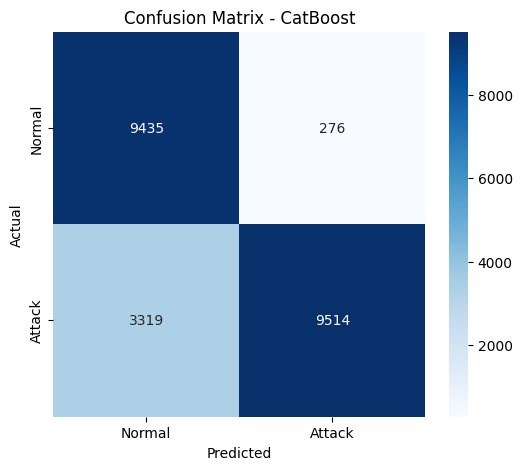

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost")
plt.show()


In [10]:
import joblib

joblib.dump(cat_model, "catboost_nslkdd_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [1]:
import joblib

# Load model
cat_model_loaded = joblib.load("catboost_nslkdd_model.pkl")

print("Model loaded successfully!")


Model loaded successfully!


In [5]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np


def get_metrics(model, X, y):
    preds = model.predict(X)

    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)             # recall for class 1
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)
    f1 = f1_score(y, preds)

    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc


# TRAIN METRICS
tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(cat_model_loaded, X_train_bal, y_train_bal)

train_df = pd.DataFrame([[
    f"{tr_acc*100:.2f}%",
    f"{tr_sens*100:.2f}%",
    f"{tr_spec*100:.2f}%",
    f"{tr_f1*100:.2f}%",
    f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
]], columns=["Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"])

print("Metrics for Catboost Model")
print("\n TRAIN METRICS")
display(train_df)


# TEST METRICS
te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(cat_model_loaded, X_test_raw, y_test)

test_df = pd.DataFrame([[
    f"{te_acc*100:.2f}%",
    f"{te_sens*100:.2f}%",
    f"{te_spec*100:.2f}%",
    f"{te_f1*100:.2f}%",
    f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
]], columns=["Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"])

print("\n TEST METRICS")
display(test_df)


Metrics for Catboost Model

 TRAIN METRICS


,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,99.95%,99.94%,99.96%,99.95%,1.0000



 TEST METRICS


,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,84.05%,74.14%,97.16%,84.11%,0.9102
